In [1]:
import pandas as pd
import plotly.express as px
import math 

In [2]:
f1 = '../data/investigadores_snii/conjunto_de_datos/investigadores_snii_historico.csv'
f2 = '../data/patentes_mexicanas/conjunto_de_datos/patentes_mexicanas.csv'
investigadores = pd.read_csv(f1)
patentes = pd.read_csv(f2)

In [3]:
mascara_1 = patentes['País'] == 'México'
patentes_mexicanas = patentes[mascara_1]
patentes_mexicanas

,País,Acumulado,1993,1994,1995,1996,1997,1998,1999,2000,...,2018,2019,2020,2021,2022,2023,2024,1T 2025 P,2T 2025 P,3T 2025 P
120,México,9494,343,288,148,116,112,141,120,118,...,457,438,397,618,507,575,700,192,225,254


In [4]:
patentes_mexicanas.rename(columns = {'Acumulado ': 'Acumulado',
                                     '1T 2025 P':'Trimestre_1',
                                     '2T 2025 P':'Trimestre_2',
                                     '3T 2025 P':'Trimestre_3',
                                     }, inplace = True)

In [5]:
patentes_mexicanas.columns

Index(['País', 'Acumulado', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016',
       '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       'Trimestre_1', 'Trimestre_2', 'Trimestre_3'],
      dtype='str')

In [6]:
columnas = ['Acumulado', '1993','1994','1995','1996','1997','1998','1999','2000','2001','2002','2003','2004','2005',
            '2006','2007','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020',
            '2021','2022','2023','2024','Trimestre_1','Trimestre_2','Trimestre_3']

for columna in columnas:
    
    patentes_mexicanas[columna] = (patentes_mexicanas[columna]
                        .astype(str) 
                        .str.replace(r'[^0-9.]', '', regex=True))
    
    patentes_mexicanas[columna] = pd.to_numeric(patentes_mexicanas[columna], errors='coerce')

In [7]:
patentes_mexicanas['2025'] = (patentes_mexicanas['Trimestre_1'] + patentes_mexicanas['Trimestre_2'] + patentes_mexicanas['Trimestre_3'])
patentes_mexicanas['2025'] = patentes_mexicanas['2025'].apply(math.ceil)
columnas_a_eliminar = ['Trimestre_1', 'Trimestre_2', 'Trimestre_3']
mascara_2 = ~patentes_mexicanas.columns.isin(columnas_a_eliminar)
patentes_mexicanas = patentes_mexicanas.iloc[:,mascara_2]
patentes_mexicanas

,País,Acumulado,1993,1994,1995,1996,1997,1998,1999,2000,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
120,México,9494,343,288,148,116,112,141,120,118,...,426,407,457,438,397,618,507,575,700,671


In [8]:
patentes_mexicanas = patentes_mexicanas.melt(
                     id_vars=['País'], 
                     var_name='Año', 
                     value_name='no_patentes'
)

patentes_mexicanas.head()

,País,Año,no_patentes
0,México,Acumulado,9494
1,México,1993,343
2,México,1994,288
3,México,1995,148
4,México,1996,116


In [9]:
columnas = ['Año']

for columna in columnas:
    
    patentes_mexicanas[columna] = (patentes_mexicanas[columna]
                        .astype(str) 
                        .str.replace(r'[^0-9.]', '', regex=True))
    
    patentes_mexicanas[columna] = pd.to_numeric(patentes_mexicanas[columna], errors='coerce')

In [10]:
investigadores_y_patentes = investigadores.merge(patentes_mexicanas, on = 'Año', how = 'inner')
eliminar = ['País']
mascara_2 = ~investigadores_y_patentes.columns.isin(eliminar)
investigadores_y_patentes = investigadores_y_patentes.iloc[:,mascara_2]
investigadores_y_patentes = investigadores_y_patentes.sort_values('Año')
investigadores_y_patentes

,Año,No_de_investigadores_reconocidos_por_el_snii,no_patentes
24,2000,7466,118
23,2001,8018,118
22,2002,9199,139
21,2003,9199,121
20,2004,10189,162
19,2005,10904,131
18,2006,12096,132
17,2007,13485,199
16,2008,14681,197
15,2009,15565,213


Se utilizan patentes concedidas a titulares mexicanos como el indicador más riguroso de innovación nacional, descartando solicitudes para evitar el sesgo de protección industrial extranjera en territorio nacional.

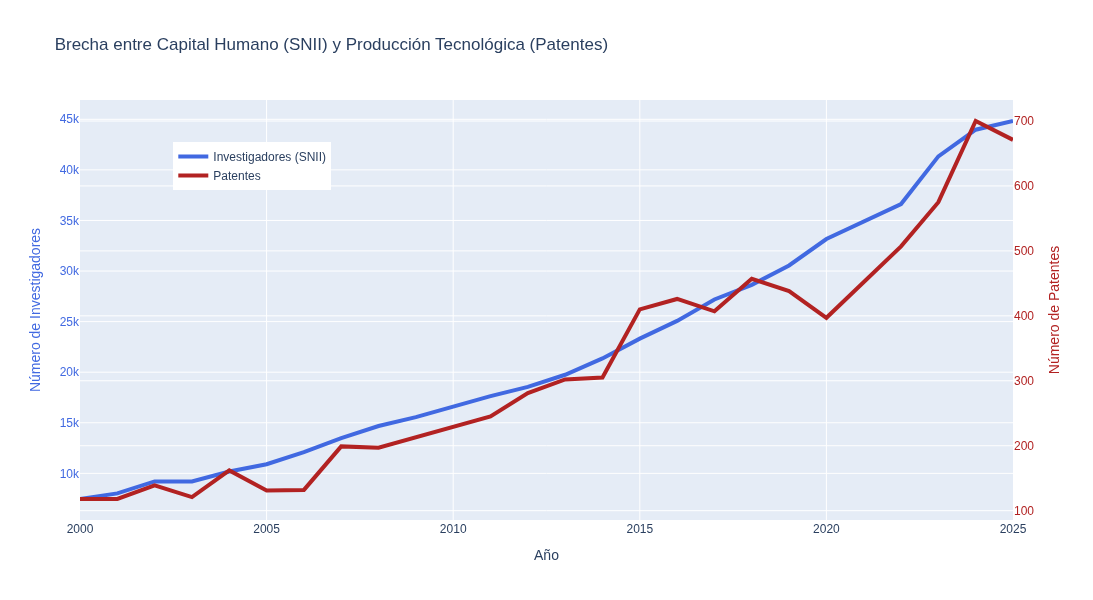

In [11]:
import plotly.graph_objects as go

figura = go.Figure()

figura.add_trace(go.Scatter(
       x=investigadores_y_patentes['Año'], 
       y=investigadores_y_patentes['No_de_investigadores_reconocidos_por_el_snii'],
       name="Investigadores (SNII)",
       line=dict(color='royalblue', width=4)
))

figura.add_trace(go.Scatter(
       x=investigadores_y_patentes['Año'], 
       y=investigadores_y_patentes['no_patentes'],
       name="Patentes",
       yaxis="y2",
       line=dict(color='firebrick', width=4)
))

figura.update_layout(
       title='Brecha entre Capital Humano (SNII) y Producción Tecnológica (Patentes)',
       xaxis=dict(title=dict(text='Año')),
       yaxis=dict(
           title=dict(
               text='Número de Investigadores',
               font=dict(color="royalblue")
           ),
           tickfont=dict(color="royalblue")
       ),
       yaxis2=dict(
           title=dict(
               text='Número de Patentes',
               font=dict(color="firebrick")
           ),
           tickfont=dict(color="firebrick"),
           overlaying='y',
           side='right'
       ),
       legend=dict(x=0.1, y=0.9),
       width=900,
       height=600
)

figura.show()